# Rede Neural e SHAP — Previsão de notícias sobre carros elétricos no Motor1

**Disciplina:** Perspectiva em Ciência de Dados  
**Projeto:** Análise de notícias automotivas do Motor1 Brasil (2016–2026)

---

## Pergunta da etapa

> A partir da matriz Bag of Words construída no pré-processamento textual, é possível treinar uma rede neural capaz de identificar notícias associadas a carros elétricos e explicar quais termos sustentam essa classificação?

## Objetivo

Este notebook usa o arquivo `bow_motor1.csv`, gerado anteriormente pelo notebook de PLN, para:

1. construir uma variável-alvo binária para notícias que mencionam carros elétricos;
2. treinar uma rede neural do tipo `MLPClassifier` sobre a matriz Bag of Words;
3. avaliar o desempenho do modelo com uma tabela consolidada de métricas de classificação binária;
4. produzir gráficos de desempenho, incluindo matriz de confusão, curva ROC e curva Precisão-Revocação;
5. produzir gráficos SHAP semelhantes ao notebook de referência de explicabilidade;
6. documentar decisões metodológicas e limitações relevantes para um projeto acadêmico.

## Relação com a análise temporal do projeto

A análise temporal anexada indicou a evolução de termos ligados à eletrificação no período 2016–2026. Este notebook complementa aquela etapa com uma tarefa preditiva: em vez de observar apenas a frequência temporal dos termos, o objetivo aqui é verificar se a matriz textual permite reconhecer notícias associadas à eletrificação e quais palavras influenciam essa classificação.

## Identidade visual do notebook

Os gráficos usam uma paleta científica e neutra, com contraste adequado para leitura acadêmica. A escolha visual privilegia legibilidade, distinção entre classes e interpretação direta dos resultados.



---
## 1. Importações e configuração inicial

O modelo escolhido é uma rede neural multicamadas (`MLPClassifier`) da biblioteca `scikit-learn`. Essa escolha mantém o notebook simples de reproduzir em ambiente acadêmico, sem exigir TensorFlow ou PyTorch.

Para explicabilidade, usamos SHAP com `KernelExplainer`, que é independente do tipo de modelo. Como esse método pode ser caro em matrizes de texto com milhares de termos, o notebook reduz o vocabulário para as features mais informativas antes do treinamento.


In [1]:
from pathlib import Path
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MaxAbsScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# configuração visual geral dos gráficos
CORES = {
    "positivo": "#0072B2",
    "negativo": "#D55E00",
    "neutro": "#4D4D4D",
    "grade": "#D9D9D9",
    "fundo": "#FFFFFF",
}

plt.rcParams.update({
    "figure.facecolor": CORES["fundo"],
    "axes.facecolor": CORES["fundo"],
    "axes.edgecolor": CORES["neutro"],
    "axes.labelcolor": CORES["neutro"],
    "xtick.color": CORES["neutro"],
    "ytick.color": CORES["neutro"],
    "text.color": CORES["neutro"],
    "axes.titleweight": "bold",
    "axes.titlepad": 12,
    "font.size": 11,
    "figure.figsize": (7, 4.5),
})

# caminho flexível para funcionar tanto no repositório quanto em execução local
NOTEBOOK_DIR = Path.cwd()
CANDIDATOS_DADOS = [
    NOTEBOOK_DIR / "dados",
    NOTEBOOK_DIR.parent / "dados",
    NOTEBOOK_DIR.parent.parent / "dados",
    Path("/mnt/data"),
]

DATA_DIR = next((p for p in CANDIDATOS_DADOS if (p / "bow_motor1.csv").exists()), CANDIDATOS_DADOS[0])
ARQUIVO_BOW = DATA_DIR / "bow_motor1.csv"

print(f"diretório de dados: {DATA_DIR}")
print(f"arquivo bow: {ARQUIVO_BOW}")
print(f"arquivo existe? {ARQUIVO_BOW.exists()}")


diretório de dados: C:\Users\bella\projeto-2-de-perspectiva-em-ciencia-de-dados\projeto\dados
arquivo bow: C:\Users\bella\projeto-2-de-perspectiva-em-ciencia-de-dados\projeto\dados\bow_motor1.csv
arquivo existe? True


---
## 2. Carregamento da matriz BoW

O arquivo `bow_motor1.csv` deve conter metadados da notícia e colunas com prefixo `bow_`, conforme produzido no notebook anterior:

- `id_noticia`, `data_publicacao`, `ano`, `categoria`, `autor`, `titulo`, `url`;
- colunas `bow_termo`, representando a frequência de cada termo no texto processado.


In [2]:
df = pd.read_csv(ARQUIVO_BOW, parse_dates=["data_publicacao"])

colunas_bow = [col for col in df.columns if col.startswith("bow_")]
metadados = [col for col in df.columns if not col.startswith("bow_")]

print(f"total de notícias: {len(df):,}")
print(f"total de termos bow: {len(colunas_bow):,}")
print("metadados:", metadados)

df.head()

total de notícias: 26,592
total de termos bow: 3,923
metadados: ['id_noticia', 'data_publicacao', 'ano', 'categoria', 'autor', 'titulo', 'url', 'palavras_unicas']


,id_noticia,data_publicacao,ano,categoria,autor,titulo,url,bow_abaixo,bow_abandonar,bow_abarth,...,bow_yuan,bow_zeekr,bow_zen,bow_zero,bow_zf,bow_zoe,bow_zona,bow_zonas,bow_zr,palavras_unicas
0,122249,2016-01-21 07:25:11,2016,Geral,Por:Redação,"Flagra: Volkswagen Ameo aparece ""limpo"" pela p...",https://motor1.uol.com.br/news/122249/flagra-v...,0,0,0,...,0,0,0,0,0,0,0,0,0,53
1,126661,2016-02-03 15:27:27,2016,"Geral, Motos",Por:Daniel Messeder,Teste: Ducati Scrambler é o MINI Cooper das mo...,https://motor1.uol.com.br/news/126661/teste-du...,0,0,0,...,0,0,0,0,0,0,0,0,0,353
2,126664,2016-02-29 16:32:24,2016,Geral,Por:Daniel Messeder,A dúvida do ano! Fiat Toro encara Jeep Renegad...,https://motor1.uol.com.br/news/126664/a-duvida...,0,0,0,...,0,0,0,0,1,0,0,0,0,474
3,123674,2016-03-08 15:30:05,2016,Geral,Por:Daniel Messeder,Teste CARPLACE: Golf GTI nacional anda mais qu...,https://motor1.uol.com.br/news/123674/teste-ca...,0,0,0,...,0,0,0,0,0,0,0,0,0,341
4,126665,2016-03-03 14:05:41,2016,Geral,Por:Daniel Messeder,Teste CARPLACE: VW Gol 2017 tenta revanche con...,https://motor1.uol.com.br/news/126665/teste-ca...,0,0,0,...,0,0,0,0,0,0,0,0,0,403


---
## 3. Construção da variável-alvo

Como este notebook parte da matriz BoW, a variável-alvo precisa ser inferida a partir dos próprios termos vetorizados. Consideramos como notícia sobre carros elétricos aquela que contém pelo menos um termo ligado diretamente à eletrificação, como `eletrico`, `eletrica`, `eletricos`, `eletricas`, `eletrificacao` ou variações de `eletrificado`.

Essa decisão é coerente com a análise temporal do projeto, que também tratou a eletrificação como um conjunto de termos textuais. Entretanto, existe uma limitação: uma matriz BoW perde a ordem das palavras, então ela não diferencia perfeitamente “motor elétrico” de “vidro elétrico”. Por isso, esta etapa deve ser interpretada como classificação de notícias com vocabulário associado à eletrificação, não como uma rotulagem humana definitiva.

Para reduzir vazamento de informação, as colunas usadas diretamente para criar o alvo serão removidas da matriz explicativa antes do treinamento. Assim, a rede neural precisa aprender o contexto textual ao redor do tema, e não apenas repetir a regra que criou o rótulo.


In [3]:
# termos usados para criar o alvo binário
PADRAO_ALVO = re.compile(
    r"^bow_(eletric|eletrif|eletrico|eletricos|eletrica|eletricas|eletrificacao|eletrificado|eletrificada|eletrificados|eletrificadas)",
    flags=re.IGNORECASE,
)

colunas_alvo = [col for col in colunas_bow if PADRAO_ALVO.search(col)]

if not colunas_alvo:
    termos_disponiveis = [col.replace("bow_", "") for col in colunas_bow if "ele" in col.lower()][:30]
    raise ValueError(
        "nenhuma coluna bow_ associada a eletrificação foi encontrada. "
        f"exemplos de termos com 'ele': {termos_disponiveis}"
    )

df["alvo_eletrico"] = (df[colunas_alvo].sum(axis=1) > 0).astype(int)

print("colunas usadas para criar o alvo:")
print(colunas_alvo)
print()
print(df["alvo_eletrico"].value_counts().rename(index={0: "não elétrico", 1: "elétrico"}))
print()
print("proporção da classe positiva:")
print(df["alvo_eletrico"].mean().round(4))

colunas usadas para criar o alvo:
['bow_eletrica', 'bow_eletricas', 'bow_eletrico', 'bow_eletricos', 'bow_eletrificacao', 'bow_eletrificada', 'bow_eletrificadas', 'bow_eletrificado', 'bow_eletrificados']

alvo_eletrico
não elétrico    16570
elétrico        10022
Name: count, dtype: int64

proporção da classe positiva:
0.3769


---
## 4. Preparação da matriz de modelagem

A matriz de entrada `X` é formada apenas por colunas BoW numéricas. As colunas usadas para criar o alvo são removidas para reduzir vazamento direto.

Além disso, aplicamos seleção de variáveis com `chi2`. Em texto, essa técnica é comum porque identifica termos cuja distribuição difere entre as classes. A redução também torna o SHAP viável computacionalmente.


In [4]:
# remove do treino as palavras que definiram diretamente o rótulo
colunas_modelo = [col for col in colunas_bow if col not in colunas_alvo]

X = df[colunas_modelo].astype(np.float32)
y = df["alvo_eletrico"].astype(int)

if y.nunique() != 2:
    raise ValueError("o alvo precisa ter duas classes para treinar a classificação binária.")

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

K_FEATURES = min(300, X_treino.shape[1])

print(f"shape X treino original: {X_treino.shape}")
print(f"shape X teste original : {X_teste.shape}")
print(f"features selecionadas  : {K_FEATURES}")
print()
print("distribuição no treino:")
print(y_treino.value_counts(normalize=True).round(4))
print()
print("distribuição no teste:")
print(y_teste.value_counts(normalize=True).round(4))

shape X treino original: (21273, 3914)
shape X teste original : (5319, 3914)
features selecionadas  : 300

distribuição no treino:
alvo_eletrico
0    0.6231
1    0.3769
Name: proportion, dtype: float64

distribuição no teste:
alvo_eletrico
0    0.623
1    0.377
Name: proportion, dtype: float64


---
## 5. Treinamento da rede neural

A rede neural usada tem duas camadas ocultas, com 64 e 32 neurônios. A entrada é a matriz BoW selecionada e reescalada por `MaxAbsScaler`, uma normalização apropriada para dados esparsos e não negativos.

Como a classe positiva pode ser minoritária, o notebook calcula pesos de amostra balanceados. Caso a versão instalada do `scikit-learn` não aceite `sample_weight` em `MLPClassifier`, o treinamento segue sem pesos, mas essa limitação é informada.


In [5]:
modelo = Pipeline(steps=[
    ("seletor", SelectKBest(score_func=chi2, k=K_FEATURES)),
    ("escala", MaxAbsScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=120,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=10,
        random_state=RANDOM_STATE,
    )),
])

pesos_treino = compute_sample_weight(class_weight="balanced", y=y_treino)

try:
    modelo.fit(X_treino, y_treino, mlp__sample_weight=pesos_treino)
    print("treinamento concluído com pesos de classe balanceados.")
except TypeError:
    modelo.fit(X_treino, y_treino)
    print("treinamento concluído sem sample_weight; a versão local do scikit-learn não aceitou pesos no MLPClassifier.")

print(f"iterações executadas: {modelo.named_steps['mlp'].n_iter_}")
print(f"loss final: {modelo.named_steps['mlp'].loss_:.5f}")

treinamento concluído com pesos de classe balanceados.
iterações executadas: 29
loss final: 0.18970


---
## 6. Avaliação do modelo

Para classificação binária, a acurácia isolada pode ser insuficiente, especialmente quando as classes são desbalanceadas. Por isso, a avaliação foi consolidada em uma tabela única com métricas de erro, acerto e separação probabilística.

A tabela inclui:

- **acurácia:** proporção total de classificações corretas;
- **acurácia balanceada:** média do acerto entre as duas classes;
- **precisão / VPP:** entre as notícias previstas como elétricas, proporção que realmente pertence à classe positiva;
- **VPN:** entre as notícias previstas como não elétricas, proporção que realmente pertence à classe negativa;
- **sensibilidade / recall:** capacidade de recuperar notícias da classe elétrica;
- **especificidade:** capacidade de reconhecer notícias não elétricas;
- **F1-score:** média harmônica entre precisão e recall;
- **ROC AUC:** área sob a curva ROC;
- **Average Precision:** área resumida sob a curva Precisão-Revocação;
- **FPR e FNR:** taxas de falso positivo e falso negativo.

A matriz de confusão é usada como base para VPP, VPN, sensibilidade, especificidade, FPR e FNR.



In [6]:
proba_teste = modelo.predict_proba(X_teste)[:, 1]
pred_teste = (proba_teste >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_teste, pred_teste, labels=[0, 1]).ravel()

acuracia = accuracy_score(y_teste, pred_teste)
acuracia_balanceada = balanced_accuracy_score(y_teste, pred_teste)
precisao = precision_score(y_teste, pred_teste, zero_division=0)
vpp = tp / (tp + fp) if (tp + fp) > 0 else 0
vpn = tn / (tn + fn) if (tn + fn) > 0 else 0
sensibilidade = recall_score(y_teste, pred_teste, zero_division=0)
especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_teste, pred_teste, zero_division=0)
roc_auc = roc_auc_score(y_teste, proba_teste)
average_precision = average_precision_score(y_teste, proba_teste)
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

metricas = {
    "acurácia": acuracia,
    "acurácia balanceada": acuracia_balanceada,
    "precisão": precisao,
    "vpp": vpp,
    "vpn": vpn,
    "sensibilidade_recall": sensibilidade,
    "especificidade": especificidade,
    "f1_score": f1,
    "roc_auc_curva_roc": roc_auc,
    "average_precision_curva_pr": average_precision,
    "fpr_taxa_falso_positivo": fpr,
    "fnr_taxa_falso_negativo": fnr,
}

df_metricas = (
    pd.DataFrame({
        "métrica": list(metricas.keys()),
        "valor": list(metricas.values()),
    })
    .assign(valor=lambda dados: dados["valor"].round(4))
)

contagens_confusao = pd.DataFrame({
    "componente": [
        "verdadeiro negativo",
        "falso positivo",
        "falso negativo",
        "verdadeiro positivo",
    ],
    "valor": [tn, fp, fn, tp],
})

print("tabela consolidada de métricas da rede neural")
display(df_metricas)

print("componentes da matriz de confusão")
display(contagens_confusao)


tabela consolidada de métricas da rede neural


,métrica,valor
0,acurácia,0.8434
1,acurácia balanceada,0.8416
2,precisão,0.7695
3,vpp,0.7695
4,vpn,0.8944
5,sensibilidade_recall,0.8344
6,especificidade,0.8488
7,f1_score,0.8007
8,roc_auc_curva_roc,0.9196
9,average_precision_curva_pr,0.8970


componentes da matriz de confusão


,componente,valor
0,verdadeiro negativo,2813
1,falso positivo,501
2,falso negativo,332
3,verdadeiro positivo,1673


In [7]:
print(classification_report(
    y_teste,
    pred_teste,
    target_names=["não elétrico", "elétrico"],
    zero_division=0,
))

              precision    recall  f1-score   support

não elétrico       0.89      0.85      0.87      3314
    elétrico       0.77      0.83      0.80      2005

    accuracy                           0.84      5319
   macro avg       0.83      0.84      0.84      5319
weighted avg       0.85      0.84      0.84      5319



---
## 7. Gráficos de desempenho

A matriz de confusão mostra erros e acertos por classe. As curvas ROC e Precisão-Revocação mostram o comportamento do classificador em diferentes limiares de decisão.


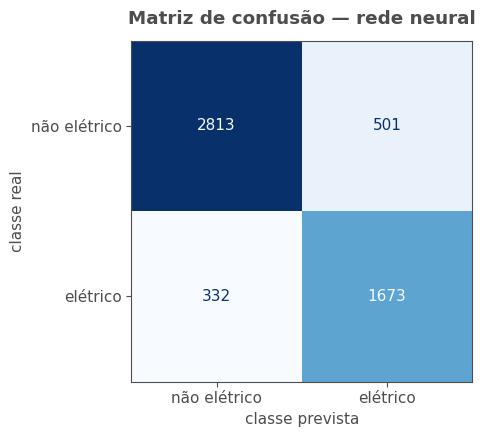

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_teste,
    pred_teste,
    display_labels=["não elétrico", "elétrico"],
    values_format="d",
    cmap="Blues",
    ax=ax,
    colorbar=False,
)
ax.set_title("Matriz de confusão — rede neural")
ax.set_xlabel("classe prevista")
ax.set_ylabel("classe real")
plt.tight_layout()
plt.show()


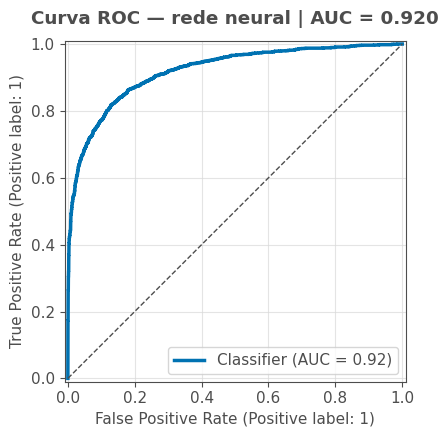

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
RocCurveDisplay.from_predictions(
    y_teste,
    proba_teste,
    ax=ax,
    color=CORES["positivo"],
    linewidth=2.5,
)
ax.plot([0, 1], [0, 1], linestyle="--", color=CORES["neutro"], linewidth=1)
ax.set_title(f"Curva ROC — rede neural | AUC = {roc_auc:.3f}")
ax.grid(color=CORES["grade"], alpha=0.7)
plt.tight_layout()
plt.show()


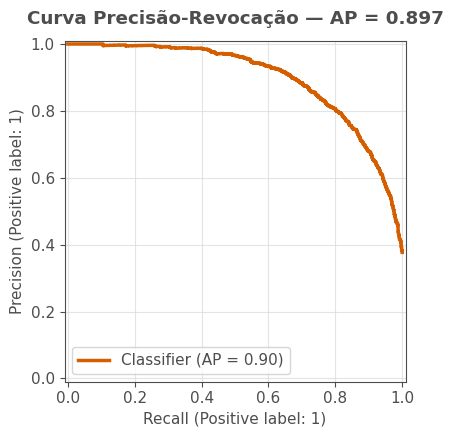

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
PrecisionRecallDisplay.from_predictions(
    y_teste,
    proba_teste,
    ax=ax,
    color=CORES["negativo"],
    linewidth=2.5,
)
ax.set_title(f"Curva Precisão-Revocação — AP = {average_precision:.3f}")
ax.grid(color=CORES["grade"], alpha=0.7)
plt.tight_layout()
plt.show()


---
## 8. Visualização comparativa das métricas

O gráfico abaixo resume as principais métricas em uma escala de 0 a 1. Ele facilita a comparação visual entre desempenho global, recuperação da classe positiva, capacidade de evitar falsos positivos e qualidade da separação probabilística.



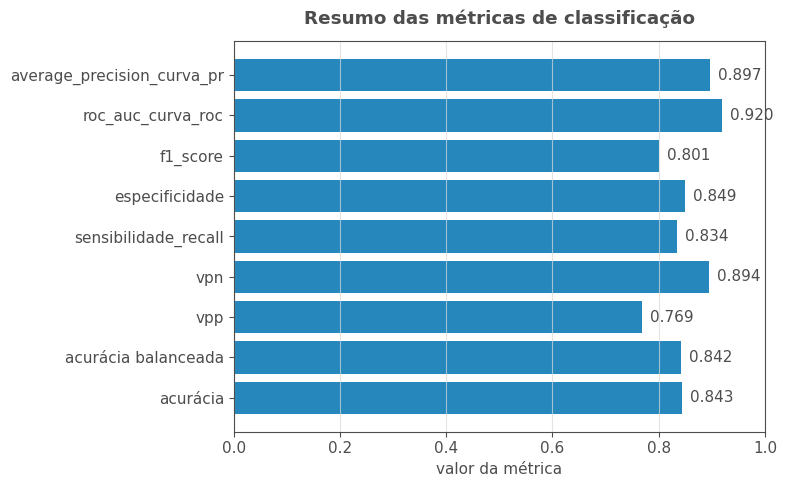

In [11]:
metricas_plot = df_metricas[df_metricas["métrica"].isin([
    "acurácia",
    "acurácia balanceada",
    "vpp",
    "vpn",
    "sensibilidade_recall",
    "especificidade",
    "f1_score",
    "roc_auc_curva_roc",
    "average_precision_curva_pr",
])].copy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(metricas_plot["métrica"], metricas_plot["valor"], color=CORES["positivo"], alpha=0.85)
ax.set_xlim(0, 1)
ax.set_xlabel("valor da métrica")
ax.set_title("Resumo das métricas de classificação")
ax.grid(axis="x", color=CORES["grade"], alpha=0.7)

for y_pos, valor in enumerate(metricas_plot["valor"]):
    ax.text(min(valor + 0.015, 0.98), y_pos, f"{valor:.3f}", va="center")

plt.tight_layout()
plt.show()


---
## 8. Inspeção das notícias com maior probabilidade prevista

Antes de aplicar SHAP, é útil observar exemplos que o modelo considera mais fortemente associados à classe positiva. Essa etapa ajuda a validar se a classificação está coerente com os títulos.


In [12]:
resultado_teste = df.loc[X_teste.index, metadados].copy()
resultado_teste["alvo_real"] = y_teste.values
resultado_teste["prob_eletrico"] = proba_teste
resultado_teste["predicao"] = pred_teste

cols_exibir = [col for col in ["data_publicacao", "ano", "categoria", "titulo", "alvo_real", "predicao", "prob_eletrico"] if col in resultado_teste.columns]

resultado_teste.sort_values("prob_eletrico", ascending=False)[cols_exibir].head(15)

,data_publicacao,ano,categoria,titulo,alvo_real,predicao,prob_eletrico
23158,2025-02-26 14:30:26,2025,Exclusivo,"""Chery de luxo"", Omoda e Jaecoo chegam em març...",1,1,1.0
22158,2024-10-09 12:42:02,2024,Tecnologia,Híbridos da Stellantis chegam em novembro; vej...,1,1,1.0
26231,2026-05-04 08:00:00,2026,Oficial,GAC i60 virá ao Brasil com 1.240 km de autonom...,1,1,1.0
24440,2025-08-12 12:00:00,2025,Colunistas,Ford anuncia nos EUA linha de elétricos acessí...,1,1,1.0
25151,2025-11-14 14:56:25,2025,Oficial,"Salão: Jeep terá Avenger, Cherokee e novo mode...",1,1,1.0
19385,2023-10-02 10:28:53,2023,Tecnologia,Tecnologia: Ford se reinventa para nova revolu...,1,1,1.0
25907,2026-03-10 09:00:00,2026,Geral,VW ID.Cross: como o 'T-Cross elétrico' se comp...,1,1,1.0
7370,2019-04-02 11:49:09,2019,Lancamentos,Novo Ford Escape 2020: SUV do Focus é revelado...,1,1,1.0
23700,2025-05-06 13:44:10,2025,Analise,Novo Jeep Compass 2026: compare o SUV atual co...,1,1,1.0
25997,2026-03-24 09:00:00,2026,Mercado,SUVs 2026: veja os lançamentos confirmados no ...,1,1,1.0


---
## 9. SHAP — preparação das amostras

O `KernelExplainer` estima a contribuição de cada termo para a probabilidade prevista pela rede neural. Como esse cálculo é custoso, usamos:

- uma amostra pequena de fundo, retirada do treino;
- uma amostra pequena do teste para explicação;
- as features já selecionadas pelo `SelectKBest`.

A interpretação dos valores SHAP neste notebook é:

> valor SHAP positivo aumenta a probabilidade prevista de a notícia ser classificada como associada a carros elétricos; valor SHAP negativo reduz essa probabilidade.


In [13]:
try:
    import shap
except ImportError as exc:
    raise ImportError(
        "instale a biblioteca shap para executar esta seção: pip install shap"
    ) from exc

seletor = modelo.named_steps["seletor"]
escala = modelo.named_steps["escala"]
mlp = modelo.named_steps["mlp"]

mask_features = seletor.get_support()
features_selecionadas = X_treino.columns[mask_features].to_list()

X_treino_sel = pd.DataFrame(
    escala.transform(seletor.transform(X_treino)),
    columns=features_selecionadas,
    index=X_treino.index,
)
X_teste_sel = pd.DataFrame(
    escala.transform(seletor.transform(X_teste)),
    columns=features_selecionadas,
    index=X_teste.index,
)

N_BACKGROUND = min(40, len(X_treino_sel))
N_EXPLICAR = min(40, len(X_teste_sel))

background = shap.sample(X_treino_sel, N_BACKGROUND, random_state=RANDOM_STATE)
amostra_shap = X_teste_sel.sample(N_EXPLICAR, random_state=RANDOM_STATE)
amostra_shap_original = X_teste.loc[amostra_shap.index, features_selecionadas]

print(f"features usadas no shap: {len(features_selecionadas)}")
print(f"amostras de fundo: {len(background)}")
print(f"amostras explicadas: {len(amostra_shap)}")

features usadas no shap: 300
amostras de fundo: 40
amostras explicadas: 40


---
## 10. Cálculo dos valores SHAP

O cálculo abaixo pode levar alguns minutos dependendo do tamanho da base e do computador. Para acelerar, reduza `N_EXPLICAR`, `N_BACKGROUND` ou `NSAMPLES`.


In [14]:
def prever_probabilidade_eletrico(matriz):
    return mlp.predict_proba(pd.DataFrame(matriz, columns=features_selecionadas))[:, 1]

explainer = shap.KernelExplainer(prever_probabilidade_eletrico, background)

NSAMPLES = 200
shap_values_array = explainer.shap_values(amostra_shap, nsamples=NSAMPLES)

if isinstance(shap_values_array, list):
    shap_values_array = shap_values_array[0]

base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = np.array(base_value).ravel()[0]

shap_values = shap.Explanation(
    values=np.array(shap_values_array),
    base_values=np.repeat(base_value, len(amostra_shap)),
    data=amostra_shap_original.values,
    feature_names=features_selecionadas,
)

print("formato dos valores shap:", shap_values.values.shape)
print(f"probabilidade base estimada: {base_value:.4f}")

indice = 0
soma_shap = shap_values.base_values[indice] + shap_values.values[indice].sum()
prob_modelo = prever_probabilidade_eletrico(amostra_shap.iloc[[indice]])[0]
print(f"base + soma(shap): {soma_shap:.4f}")
print(f"modelo.predict_proba: {prob_modelo:.4f}")

100%|██████████| 40/40 [00:03<00:00, 12.53it/s]

formato dos valores shap: (40, 300)
probabilidade base estimada: 0.4945
base + soma(shap): 0.9994
modelo.predict_proba: 0.9994


---
## 11. SHAP — importância global

O gráfico de barras ordena os termos pela média dos valores absolutos de SHAP. Ele mostra quais termos mais alteram a probabilidade prevista pela rede neural, sem indicar direção do efeito.


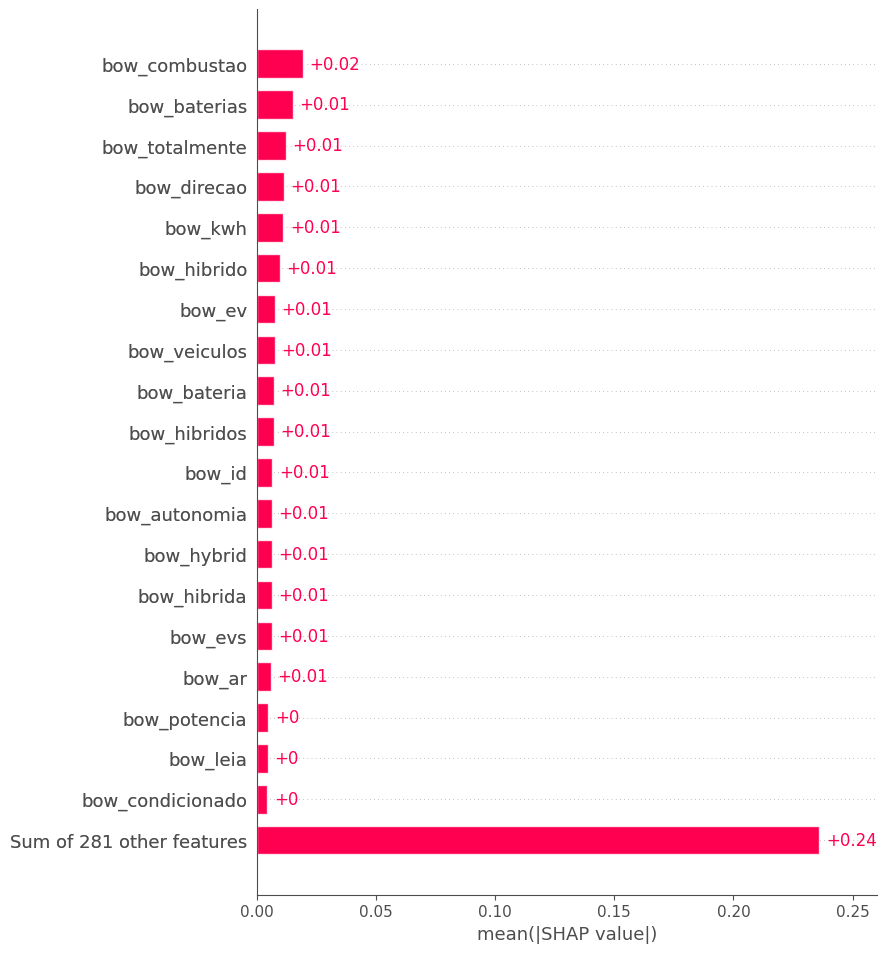

In [15]:
shap.plots.bar(shap_values, max_display=20)

---
## 12. SHAP — beeswarm

O beeswarm combina magnitude e direção:

- pontos à direita aumentam a probabilidade prevista de notícia sobre carros elétricos;
- pontos à esquerda reduzem essa probabilidade;
- a cor representa o valor original da feature na notícia, isto é, a frequência do termo no BoW.


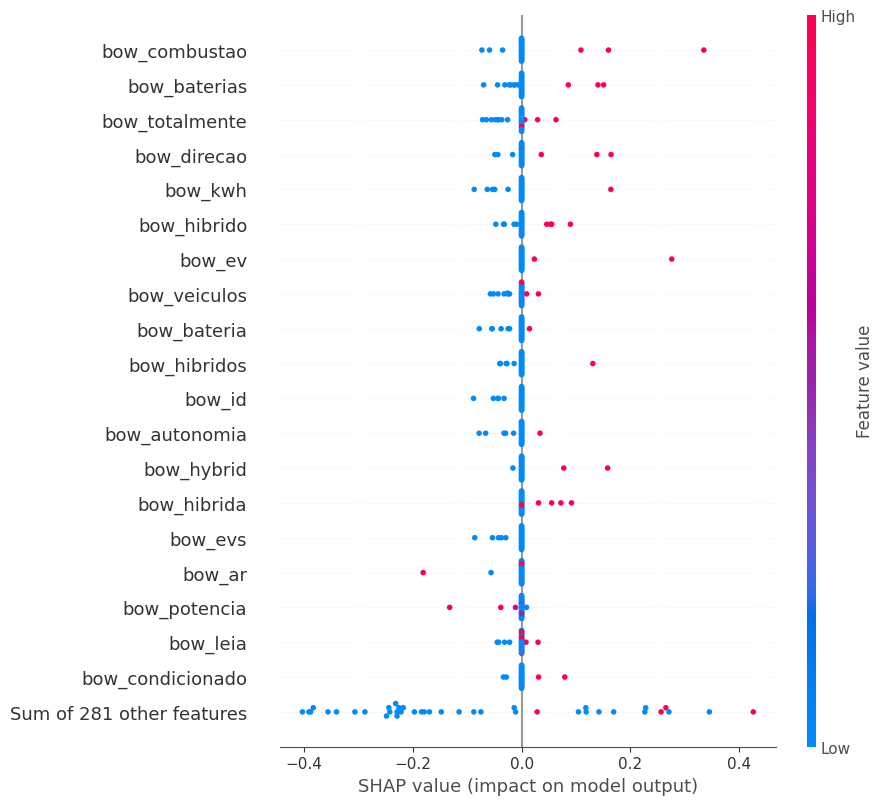

In [16]:
shap.plots.beeswarm(shap_values, max_display=20)

---
## 13. SHAP — explicação individual com waterfall

O waterfall explica uma notícia específica. Ele parte da probabilidade média estimada pelo explicador e mostra quais termos empurraram a previsão para cima ou para baixo.


título: Flagra: Novo Honda Civic testa inédita versão híbrida para 2022
alvo real: 1
probabilidade prevista: 0.9994


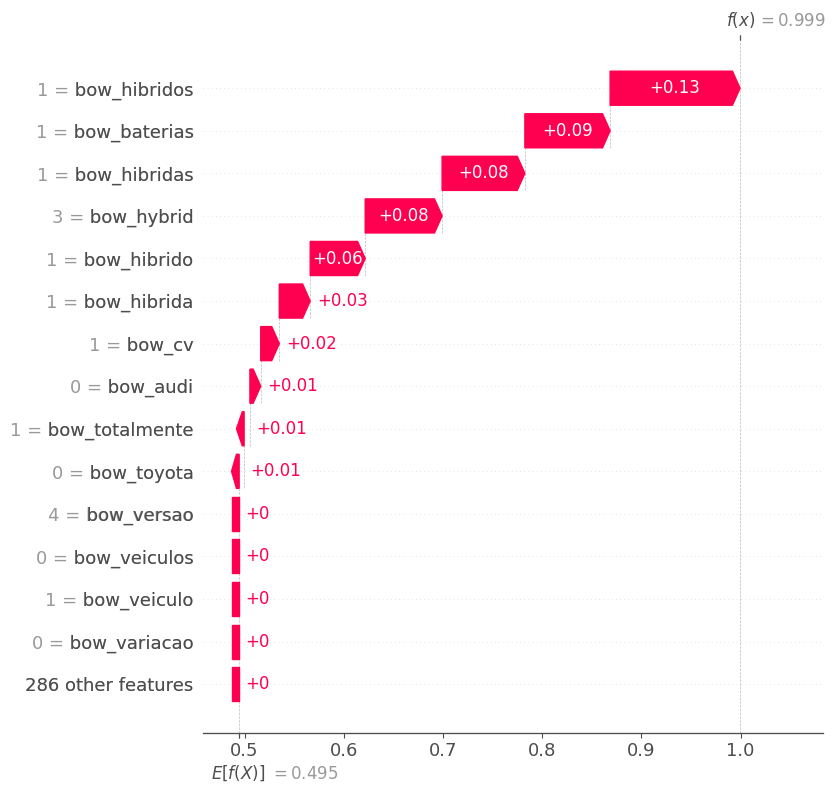

In [17]:
i = 0
idx = amostra_shap.index[i]

print("título:", df.loc[idx, "titulo"] if "titulo" in df.columns else idx)
print("alvo real:", int(df.loc[idx, "alvo_eletrico"]))
print(f"probabilidade prevista: {prever_probabilidade_eletrico(amostra_shap.iloc[[i]])[0]:.4f}")

shap.plots.waterfall(shap_values[i], max_display=15)

---
## 14. SHAP — efeito de um termo específico

O gráfico de dispersão mostra como a frequência de um termo se relaciona com sua contribuição SHAP. O termo é escolhido automaticamente entre os mais importantes globalmente, mas pode ser substituído manualmente.


termo escolhido: bow_combustao


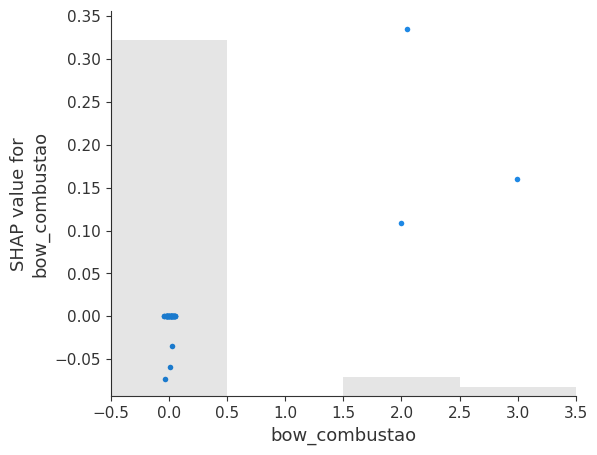

In [18]:
importancia_media = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=features_selecionadas,
).sort_values(ascending=False)

termo_escolhido = importancia_media.index[0]
print(f"termo escolhido: {termo_escolhido}")

shap.plots.scatter(shap_values[:, termo_escolhido])

---
## 16. Tabela de importância SHAP

A tabela abaixo facilita a inclusão dos resultados no relatório acadêmico. Os termos são apresentados sem o prefixo `bow_`.


In [19]:
df_importancia_shap = (
    pd.DataFrame({
        "termo": importancia_media.index.str.replace("bow_", "", regex=False),
        "media_abs_shap": importancia_media.values,
    })
    .head(30)
)

df_importancia_shap["media_abs_shap"] = df_importancia_shap["media_abs_shap"].round(6)
df_importancia_shap

,termo,media_abs_shap
0,combustao,0.019258
1,baterias,0.014930
2,totalmente,0.012157
3,direcao,0.011202
4,kwh,0.011042
5,hibrido,0.009489
6,ev,0.007486
7,veiculos,0.007441
8,bateria,0.007125
9,hibridos,0.006958


---
## 17. Salvando resultados intermediários

Esta célula salva as métricas e a importância SHAP em arquivos `.csv`, permitindo uso posterior no relatório ou em novos notebooks.


In [20]:
ARQUIVO_METRICAS = DATA_DIR / "metricas_rede_neural_eletricos.csv"
ARQUIVO_CONFUSAO = DATA_DIR / "componentes_matriz_confusao_rede_neural_eletricos.csv"
ARQUIVO_SHAP = DATA_DIR / "importancia_shap_rede_neural_eletricos.csv"

df_metricas.to_csv(ARQUIVO_METRICAS, index=False)
contagens_confusao.to_csv(ARQUIVO_CONFUSAO, index=False)
df_importancia_shap.to_csv(ARQUIVO_SHAP, index=False)

print(f"métricas salvas em: {ARQUIVO_METRICAS}")
print(f"componentes da matriz de confusão salvos em: {ARQUIVO_CONFUSAO}")
print(f"importância shap salva em: {ARQUIVO_SHAP}")


métricas salvas em: C:\Users\bella\projeto-2-de-perspectiva-em-ciencia-de-dados\projeto\dados\metricas_rede_neural_eletricos.csv
componentes da matriz de confusão salvos em: C:\Users\bella\projeto-2-de-perspectiva-em-ciencia-de-dados\projeto\dados\componentes_matriz_confusao_rede_neural_eletricos.csv
importância shap salva em: C:\Users\bella\projeto-2-de-perspectiva-em-ciencia-de-dados\projeto\dados\importancia_shap_rede_neural_eletricos.csv


---
## 18. Discussão metodológica

A abordagem deste notebook é adequada como experimento de classificação textual com matriz BoW, mas tem limitações importantes:

1. **Rótulo heurístico:** a classe `alvo_eletrico` foi construída a partir de termos textuais, não por anotação humana. Portanto, o modelo aprende a reconhecer um padrão operacional de menção à eletrificação.
2. **Perda de contexto do BoW:** a matriz Bag of Words ignora a ordem das palavras. Isso limita a distinção entre usos como `motor elétrico` e `vidro elétrico`.
3. **Risco de vazamento reduzido, mas não eliminado:** os termos usados diretamente para criar o alvo foram removidos do treino. Mesmo assim, termos correlacionados podem funcionar como atalhos semânticos.
4. **SHAP em rede neural:** o `KernelExplainer` é model-agnostic e aproximado. Ele é útil para interpretação, mas seus resultados podem variar com o tamanho da amostra de fundo e o número de simulações.
5. **Interpretação substantiva:** os termos mais importantes devem ser lidos em conjunto com a análise temporal do projeto. Um termo relevante para classificar notícias elétricas não necessariamente prova antecipação da indústria; ele apenas indica associação textual no corpus.

## Conclusão da etapa

A rede neural permite transformar a matriz BoW em um classificador de notícias associadas à eletrificação. As métricas avaliam se o modelo separa bem as classes, enquanto os gráficos SHAP mostram quais termos mais contribuíram para essa separação. Em conjunto com a etapa temporal, essa análise ajuda a caracterizar como o tema de carros elétricos aparece no vocabulário jornalístico do Motor1 ao longo do período estudado.
